# Pronóstico de inflación con modelos univariados

**Pregunta.** ¿Puede un modelo estadístico que solo usa la historia de la inflación pronosticarla mejor que reglas simples, como suponer que se cumplirá la meta del 3%?

**Datos.** Inflación mensual del IPC entre enero de 2002 y diciembre de 2025.

**Método.** Se comparan cinco pronosticadores:

| Modelo | Cómo pronostica |
|---|---|
| Meta 3% | Supone inflación anual de 3%, repartida en partes iguales cada mes |
| Promedio 12 meses | Repite el promedio de los últimos doce meses |
| Estacional ingenuo | Repite lo ocurrido el mismo mes del año anterior |
| SARIMA | Modelo autorregresivo con media móvil y componente estacional |
| ETS | Suavizamiento exponencial con estacionalidad aditiva |

La evaluación usa origen móvil: cada mes desde diciembre de 2011, cada modelo se reestima con los datos disponibles a esa fecha y pronostica los doce meses siguientes. Así se mide el desempeño que se habría tenido en tiempo real.

**Resultado principal.** El SARIMA tiene el menor error para la inflación acumulada de doce meses, pero la diferencia con la meta del 3% no es estadísticamente significativa. Antes de la pandemia, suponer que se cumplía la meta era tan preciso como cualquier modelo. Ningún modelo univariado anticipó el shock inflacionario de 2021 y 2022.

## 1. Configuración y datos

In [1]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from dsaplicado import datos, series as st
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

# statsmodels avisa de problemas de convergencia en algunas ventanas; se revisan
# los resultados agregados en vez de cada ajuste individual.
warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
CARPETA = RAIZ / "03_series_de_tiempo"
(CARPETA / "figuras").mkdir(exist_ok=True)
(CARPETA / "resultados").mkdir(exist_ok=True)

ipc = datos.cargar_indicador(RAIZ / "datos" / "ipc_historico.csv", "ipc", range(1995, 2027))
ipc.index = ipc.index.to_period("M").to_timestamp()
inflacion = ipc.loc["2002":].asfreq("MS")

INICIO_EVALUACION = "2012-01-01"   # primer mes pronosticado
HORIZONTE = 12
print(f"Inflación mensual: {len(inflacion)} meses, de {inflacion.index[0]:%m-%Y} a {inflacion.index[-1]:%m-%Y}")

Inflación mensual: 288 meses, de 01-2002 a 12-2025


## 2. Selección del SARIMA

El orden del modelo se elige una sola vez, con los datos anteriores a 2012, para que la evaluación posterior sea honesta. Se prueban todas las combinaciones de órdenes bajos y se comparan con los criterios de información AIC y BIC.

In [2]:
entrenamiento = inflacion.loc[:"2011-12"]
candidatos = []
for p, q, P, Q in itertools.product([0, 1, 2], [0, 1], [0, 1], [0, 1]):
    ajuste = SARIMAX(entrenamiento, order=(p, 0, q), seasonal_order=(P, 0, Q, 12), trend="c").fit(disp=False)
    candidatos.append({"orden": f"({p},0,{q})({P},0,{Q})12", "aic": ajuste.aic, "bic": ajuste.bic})
candidatos = pd.DataFrame(candidatos).sort_values("aic").reset_index(drop=True)
candidatos.head(5)

,orden,aic,bic
0,"(0,0,1)(1,0,1)12",112.046,125.984
1,"(1,0,1)(1,0,1)12",113.102,129.827
2,"(2,0,1)(1,0,1)12",113.689,133.201
3,"(1,0,0)(1,0,1)12",115.375,129.312
4,"(2,0,0)(1,0,1)12",116.031,132.756


In [3]:
ORDEN, ORDEN_ESTACIONAL = (0, 0, 1), (1, 0, 1, 12)
modelo = SARIMAX(entrenamiento, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="c").fit(disp=False)
print(modelo.summary().tables[1])
ljung = acorr_ljungbox(modelo.resid, lags=[12, 24])
print("\nLjung-Box sobre los residuos, p-valores:", ljung["lb_pvalue"].round(3).to_dict())

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0022      0.027      0.079      0.937      -0.051       0.056
ma.L1          0.6036      0.082      7.362      0.000       0.443       0.764
ar.S.L12       0.9920      0.102      9.746      0.000       0.792       1.191
ma.S.L12      -0.9356      0.416     -2.250      0.024      -1.751      -0.120
sigma2         0.1261      0.036      3.492      0.000       0.055       0.197

Ljung-Box sobre los residuos, p-valores: {12: 0.134, 24: 0.091}


AIC y BIC coinciden en el mismo modelo: una media móvil de orden uno con componentes estacionales autorregresivo y de media móvil. El coeficiente autorregresivo estacional es cercano a uno, lo que indica un patrón estacional muy estable de un año a otro. Los residuos no muestran autocorrelación significativa al 5%, así que el modelo captura la estructura de la serie en el período de entrenamiento.

## 3. Evaluación con origen móvil

In [4]:
META_MENSUAL = (1.03 ** (1 / 12) - 1) * 100

def meta_3(historia, h):
    return np.full(h, META_MENSUAL)

def promedio_12(historia, h):
    return np.full(h, historia.iloc[-12:].mean())

def estacional_ingenuo(historia, h):
    return historia.iloc[-12:].to_numpy()[:h]

def sarima(historia, h):
    ajuste = SARIMAX(historia, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="c").fit(disp=False)
    return ajuste.forecast(h).to_numpy()

def ets(historia, h):
    ajuste = ExponentialSmoothing(historia, seasonal="add", seasonal_periods=12, trend=None).fit()
    return ajuste.forecast(h).to_numpy()

MODELOS = {"Meta 3%": meta_3, "Promedio 12 meses": promedio_12, "Estacional ingenuo": estacional_ingenuo,
           "SARIMA": sarima, "ETS": ets}
evaluacion = st.evaluar_origen_movil(inflacion, MODELOS, INICIO_EVALUACION, HORIZONTE)
print(f"{evaluacion['origen'].nunique()} orígenes, de {evaluacion['origen'].min():%m-%Y} a {evaluacion['origen'].max():%m-%Y}")

157 orígenes, de 12-2011 a 12-2024


### Error por horizonte, inflación mensual

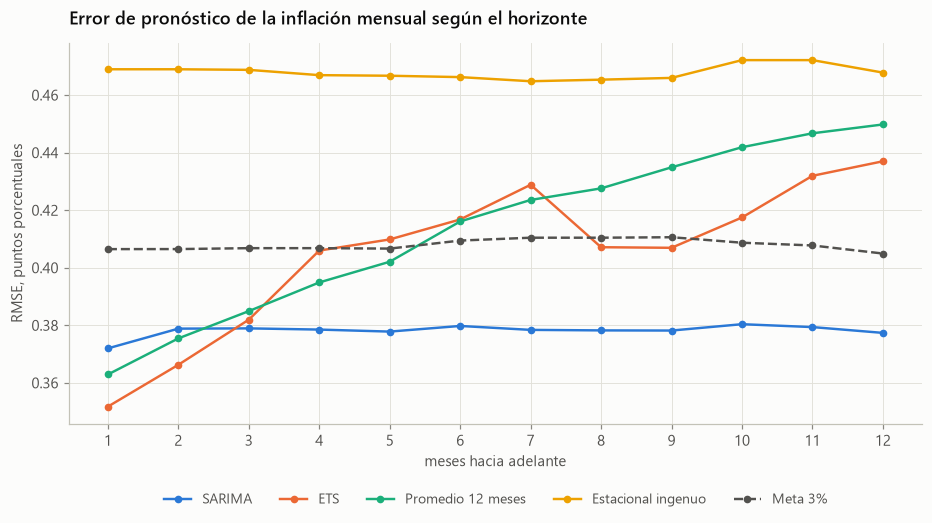

modelo,ETS,Estacional ingenuo,Meta 3%,Promedio 12 meses,SARIMA
horizonte,,,,,
1,0.352,0.469,0.406,0.363,0.372
2,0.366,0.469,0.406,0.375,0.379
3,0.382,0.469,0.407,0.385,0.379
4,0.406,0.467,0.407,0.395,0.379
5,0.410,0.467,0.407,0.402,0.378
6,0.417,0.466,0.409,0.416,0.380
7,0.429,0.465,0.410,0.424,0.378
8,0.407,0.465,0.410,0.428,0.378
9,0.407,0.466,0.411,0.435,0.378


In [5]:
rmse = st.resumen_errores(evaluacion, "rmse")
estilo = {"SARIMA": COLORES[0], "ETS": COLORES[1], "Promedio 12 meses": COLORES[2], "Estacional ingenuo": COLORES[3],
          "Meta 3%": TINTA_SECUNDARIA}

fig, ax = plt.subplots(figsize=(10, 4.5))
for nombre, color in estilo.items():
    ax.plot(rmse.index, rmse[nombre], color=color, marker="o", markersize=4,
            linestyle="--" if nombre == "Meta 3%" else "-", label=nombre)
ax.set_xticks(range(1, 13))
ax.set_xlabel("meses hacia adelante")
ax.set_ylabel("RMSE, puntos porcentuales")
ax.set_title("Error de pronóstico de la inflación mensual según el horizonte")
ax.legend(ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=9)
plt.show()
rmse.round(3)

Para el mes siguiente, el ETS y el promedio de doce meses son los más precisos, porque aprovechan la persistencia de corto plazo. Desde el tercer mes, el SARIMA es el más preciso en todos los horizontes y su error casi no crece. La meta del 3% también mantiene un error estable, mientras el ETS y el promedio se deterioran. Repetir el mismo mes del año anterior es casi siempre la peor opción, porque arrastra todo el ruido de un único mes.

### Error de la inflación acumulada en doce meses

Para un banco o un inversionista, la cifra relevante suele ser la inflación de los próximos doce meses. Se obtiene acumulando los doce pronósticos mensuales de cada origen.

In [6]:
def acumular(variaciones):
    return 100 * ((1 + variaciones / 100).prod() - 1)

acumulada = (evaluacion.groupby(["modelo", "origen"])
             .agg(pronostico=("pronostico", acumular), real=("real", acumular))
             .reset_index())
acumulada["error"] = acumulada["real"] - acumulada["pronostico"]
errores_12m = acumulada.pivot(index="origen", columns="modelo", values="error")

def rmse_de(e):
    return np.sqrt((e ** 2).mean())

resumen = pd.DataFrame({
    "RMSE total": errores_12m.apply(rmse_de),
    "RMSE hasta 2019": errores_12m.loc[:"2019-06"].apply(rmse_de),
    "sesgo medio": errores_12m.mean(),
}).sort_values("RMSE total")
resumen

,RMSE total,RMSE hasta 2019,sesgo medio
modelo,,,
SARIMA,2.924,1.230,0.775
Meta 3%,3.155,1.181,1.356
ETS,3.279,2.387,0.021
Estacional ingenuo,3.308,1.638,0.069
Promedio 12 meses,3.309,1.637,0.063


In [7]:
pruebas = pd.DataFrame({
    rival: st.prueba_diebold_mariano(errores_12m["SARIMA"], errores_12m[rival], HORIZONTE)
    for rival in errores_12m.columns if rival != "SARIMA"
}).T
pruebas.columns = ["estadístico DM", "p-valor"]
pruebas

,estadístico DM,p-valor
ETS,-0.584,0.560
Estacional ingenuo,-0.592,0.555
Meta 3%,-1.115,0.267
Promedio 12 meses,-0.591,0.555


**Lectura.**

- **El SARIMA gana, pero sin significancia.** Tiene el menor RMSE, aunque ninguna prueba de Diebold-Mariano rechaza que su precisión sea igual a la de los demás. Con trece años de orígenes y errores de doce meses que se traslapan, hay poca información independiente.
- **La meta del 3% es un rival muy fuerte en tiempos normales.** Hasta 2019 fue el pronóstico más preciso. Esto refleja la credibilidad del Banco Central: cuando las expectativas están ancladas, la inflación vuelve a la meta.
- **Todos los modelos subestiman la inflación en promedio.** El sesgo positivo viene casi entero del período 2021 y 2022.

### Pronóstico contra realidad en el tiempo

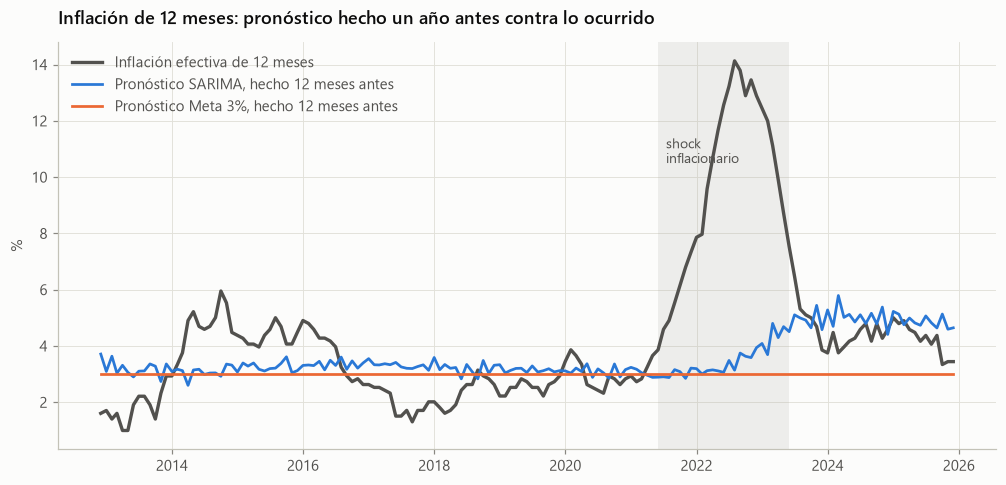

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.8))
real = acumulada[acumulada["modelo"] == "SARIMA"].set_index("origen")["real"]
fechas_objetivo = real.index + pd.DateOffset(months=12)
ax.plot(fechas_objetivo, real, color=TINTA_SECUNDARIA, linewidth=2.2, label="Inflación efectiva de 12 meses")
for nombre, color in [("SARIMA", COLORES[0]), ("Meta 3%", COLORES[1])]:
    serie = acumulada[acumulada["modelo"] == nombre].set_index("origen")["pronostico"]
    ax.plot(fechas_objetivo, serie, color=color, linewidth=1.8, label=f"Pronóstico {nombre}, hecho 12 meses antes")
ax.axvspan(pd.Timestamp("2021-06-01"), pd.Timestamp("2023-06-01"), color=NEUTRO, alpha=0.2, linewidth=0)
ax.annotate("shock" + chr(10) + "inflacionario", (pd.Timestamp("2021-07-15"), 10.5), fontsize=9, color=TINTA_SECUNDARIA)
ax.set_ylabel("%")
ax.set_title("Inflación de 12 meses: pronóstico hecho un año antes contra lo ocurrido")
ax.legend(loc="upper left")
fig.savefig(CARPETA / "figuras" / "pronostico_inflacion.png", bbox_inches="tight")
plt.show()

El gráfico muestra el límite de los modelos univariados. El SARIMA sigue de cerca la inflación cuando esta se mueve lentamente, pero no puede anticipar un shock que viene de fuera de la propia serie: el estímulo fiscal, los retiros de fondos de pensiones y los precios internacionales de 2021. Solo lo incorpora cuando ya se refleja en los datos, con un año de retraso.

## 4. Pronóstico para 2026

Con el modelo estimado sobre toda la muestra se proyecta la inflación de 2026, con intervalos de confianza.

Inflación proyectada para 2026: 4.4%, con intervalo de 80% entre 2.1% y 6.6%


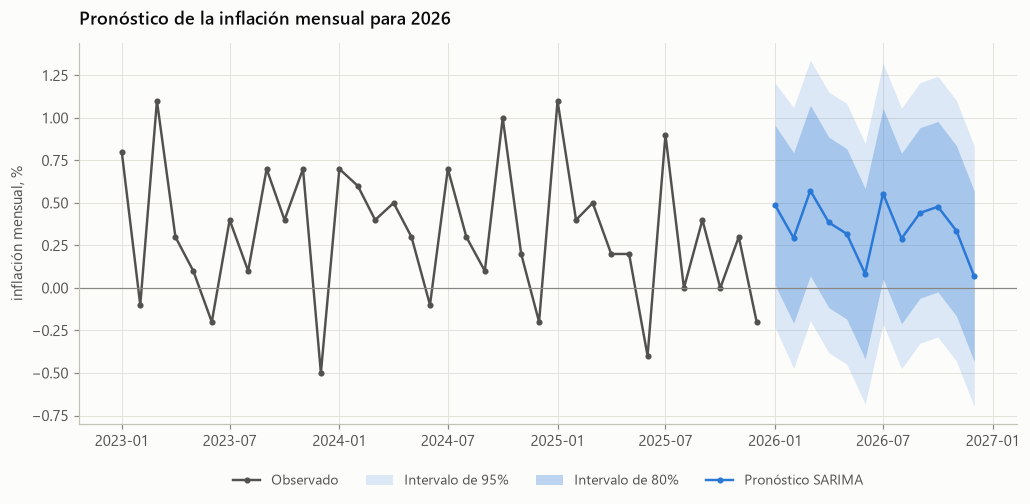

In [9]:
final = SARIMAX(inflacion, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="c").fit(disp=False)
proyeccion = final.get_forecast(HORIZONTE)
media = proyeccion.predicted_mean
banda_95 = proyeccion.conf_int(alpha=0.05)
banda_80 = proyeccion.conf_int(alpha=0.20)

# Inflación acumulada de 2026 por simulación, para obtener un intervalo del total anual.
simulaciones = final.simulate(HORIZONTE, repetitions=5000, anchor="end", rng=np.random.default_rng(7))
acumulado_2026 = 100 * ((1 + np.asarray(simulaciones).reshape(HORIZONTE, -1) / 100).prod(axis=0) - 1)
p10, p50, p90 = np.percentile(acumulado_2026, [10, 50, 90])
print(f"Inflación proyectada para 2026: {p50:.1f}%, con intervalo de 80% entre {p10:.1f}% y {p90:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4.5))
historia = inflacion.loc["2023":]
ax.plot(historia.index, historia, color=TINTA_SECUNDARIA, marker="o", markersize=3, label="Observado")
ax.fill_between(media.index, banda_95.iloc[:, 0], banda_95.iloc[:, 1], color=COLORES[0], alpha=0.15, linewidth=0,
                label="Intervalo de 95%")
ax.fill_between(media.index, banda_80.iloc[:, 0], banda_80.iloc[:, 1], color=COLORES[0], alpha=0.3, linewidth=0,
                label="Intervalo de 80%")
ax.plot(media.index, media, color=COLORES[0], marker="o", markersize=3, label="Pronóstico SARIMA")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_ylabel("inflación mensual, %")
ax.set_title("Pronóstico de la inflación mensual para 2026")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=4, fontsize=9)
plt.show()

El intervalo es amplio: la inflación mensual tiene mucho ruido y el modelo no sabe nada de lo que ocurre fuera de la serie. Este pronóstico es una referencia estadística, no un escenario macroeconómico. Se puede contrastar con la inflación efectiva de 2026 a medida que la fuente la publique.

## 5. Resultados para el notebook multivariado

Los errores de doce meses se guardan para compararlos con los modelos VAR del notebook 03 sobre exactamente los mismos orígenes.

In [10]:
salida = CARPETA / "resultados" / "errores_12m_univariados.csv"
errores_12m.to_csv(salida, float_format="%.6f")
print(f"Guardado en {salida.relative_to(RAIZ)}")

Guardado en 03_series_de_tiempo\resultados\errores_12m_univariados.csv


## 6. Conclusiones

1. **Un SARIMA simple es competitivo.** Tiene el menor error acumulado de doce meses entre los modelos univariados, aunque sin diferencias significativas.
2. **La meta del Banco Central es un pronóstico difícil de superar en períodos normales.** Cualquier modelo de inflación en Chile debería compararse contra ella.
3. **Los modelos univariados no anticipan shocks.** Solo reaccionan cuando el shock ya aparece en la serie. Anticiparlos requiere información de otras variables, que es lo que se evalúa en el notebook 03.

## 7. Limitaciones

- **Datos finales, no preliminares.** Se usan las cifras publicadas hoy. En tiempo real el IPC casi no se revisa, así que el sesgo es menor que en variables de actividad.
- **Un solo período de estrés.** El shock de 2021 y 2022 domina el error total. Con otro período de evaluación el ranking podría cambiar.
- **Redondeo de la fuente.** La inflación mensual se publica con un decimal, lo que agrega ruido a los errores de horizontes cortos.